# Otsu's Method for Segmentation

The main idea is to minimize the intra-class variance, so we use a threshold to separate the data in two sets (classes) such that:

$$\text{P}\left( \text{Class 1}\right) \cdot \text{Variance of Class 1}+\text{P}\left( \text{Class 2}\right) \cdot \text{Variance of Class 2}$$

is minimal.

https://en.wikipedia.org/wiki/Otsu%27s_method

In [1]:
#@title
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150
import matplotlib.pyplot as plt

In [2]:
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import pandas as pd


# import seaborn: very important to easily plot histograms and density estimations
import seaborn as sns

from scipy import stats
from scipy.stats import norm

In [3]:
# we create two fictitious populations (i.e. squirrels and rabbits)
data = np.concatenate((norm.rvs(size=500,loc=1.5,scale=0.3),norm.rvs(size=500,loc=5,scale=1.25)),axis=0)
#group = np.repeat([0,1],500)

/var/folders/1m/2d5xq3d16t31xt6lgcqz8wlm0000gq/T/ipykernel_7665/638789677.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(data,


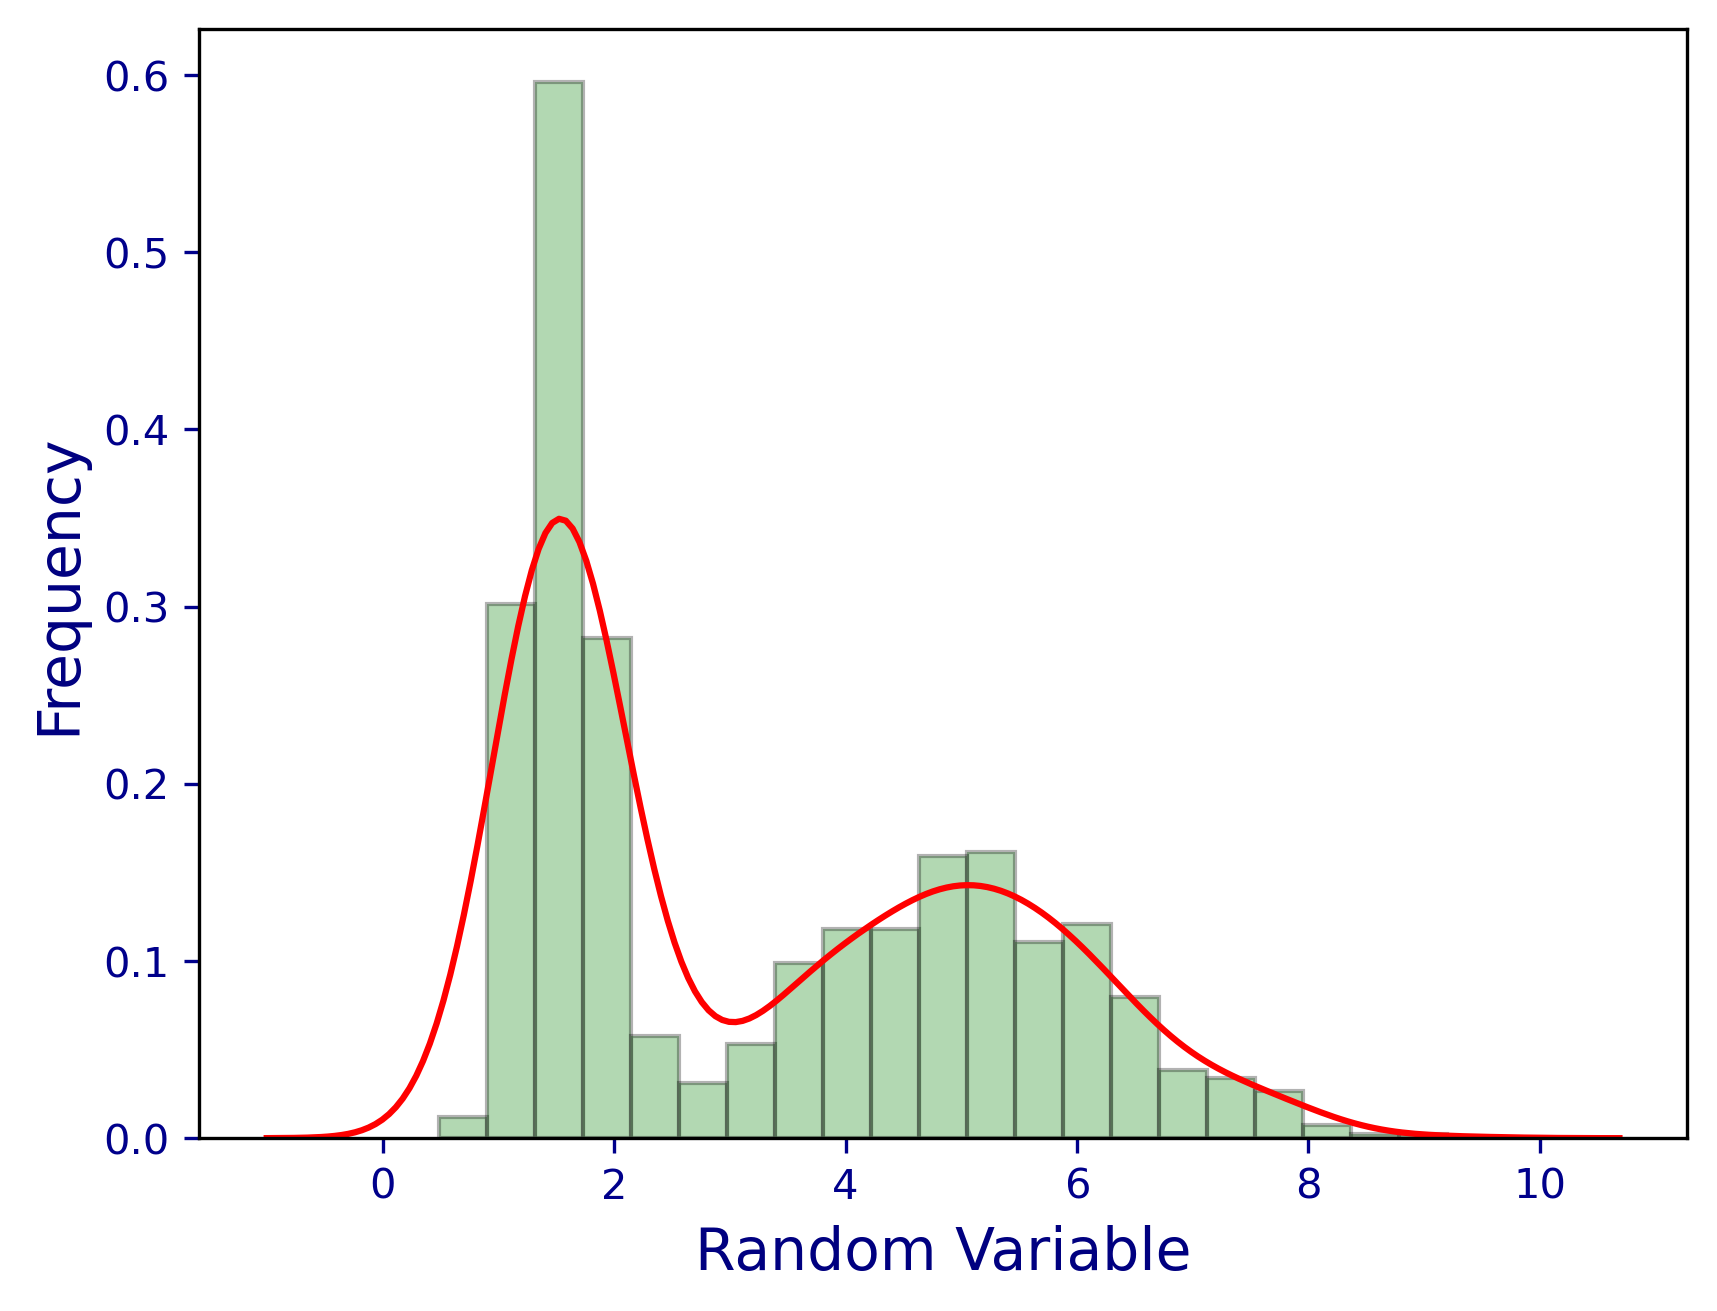

In [4]:
plt.figure()
# then we want to display the histogram and the fit of the underlying distribution:
ax1 = sns.distplot(data,
                  bins=21,
                  kde=True,
                  color='red',
                  hist_kws={'color':'green','alpha':0.3,'edgecolor':'black'},
                  #fit=stats.norm,
                  #fit_kws={"color":'deepskyblue'}
                   )
ax1.set_xlabel('Random Variable',fontsize=14,color='navy')
ax1.set_ylabel('Frequency',fontsize=14,color='navy')
l1 = ax1.lines[0]
#plt.axvline(x=3.0, color='black',linestyle='dashed')

x = l1.get_xydata()[:,0]
y = l1.get_xydata()[:,1]
plt.tick_params(axis='x', colors='darkblue')
plt.tick_params(axis='y', colors='darkblue')
#ax1.fill_between(x,y, where = x <= 3.0, color='palegreen',alpha=0.5)

In [5]:
np.var(data)

3.9201349279735513

In [6]:
# we generate equally spaced percentages (by 0.1)
t = np.linspace(0.1,99.9,num=999)

In [7]:
t = np.arange(0.1,100,0.1)

In [8]:
t

array([ 0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,  1.1,
        1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,  2.2,
        2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  3. ,  3.1,  3.2,  3.3,
        3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,  4.2,  4.3,  4.4,
        4.5,  4.6,  4.7,  4.8,  4.9,  5. ,  5.1,  5.2,  5.3,  5.4,  5.5,
        5.6,  5.7,  5.8,  5.9,  6. ,  6.1,  6.2,  6.3,  6.4,  6.5,  6.6,
        6.7,  6.8,  6.9,  7. ,  7.1,  7.2,  7.3,  7.4,  7.5,  7.6,  7.7,
        7.8,  7.9,  8. ,  8.1,  8.2,  8.3,  8.4,  8.5,  8.6,  8.7,  8.8,
        8.9,  9. ,  9.1,  9.2,  9.3,  9.4,  9.5,  9.6,  9.7,  9.8,  9.9,
       10. , 10.1, 10.2, 10.3, 10.4, 10.5, 10.6, 10.7, 10.8, 10.9, 11. ,
       11.1, 11.2, 11.3, 11.4, 11.5, 11.6, 11.7, 11.8, 11.9, 12. , 12.1,
       12.2, 12.3, 12.4, 12.5, 12.6, 12.7, 12.8, 12.9, 13. , 13.1, 13.2,
       13.3, 13.4, 13.5, 13.6, 13.7, 13.8, 13.9, 14. , 14.1, 14.2, 14.3,
       14.4, 14.5, 14.6, 14.7, 14.8, 14.9, 15. , 15

In [9]:
# here we applied Otsu's method
# the variable cost keeps track of all values of the objective
cost = []
for i in t:
  dat1 = data[data<np.percentile(data,i)]
  dat2 = data[data>=np.percentile(data,i)]
  cost.append(i*np.var(dat1)+(100-i)*np.var(dat2))

In [10]:
cost

[391.24367975605327,
 390.4916990262152,
 389.8572203015575,
 389.2443756246948,
 388.6591055607576,
 388.10376858253034,
 387.55298888883163,
 387.00683799832433,
 386.47544383839244,
 385.9448201267511,
 385.41439745538594,
 384.8901503874666,
 384.3644484368205,
 383.83842426475996,
 383.3116104511097,
 382.7841489943582,
 382.25589020457613,
 381.7300813075691,
 381.208983898293,
 380.6890152197563,
 380.1764915894705,
 379.66371853779464,
 379.152764745272,
 378.64257019306876,
 378.1326433816229,
 377.62780053227294,
 377.1244931369408,
 376.6233163920018,
 376.121080934007,
 375.6200303194084,
 375.12043048710837,
 374.62196760258996,
 374.12350198476895,
 373.62622511280773,
 373.130116875754,
 372.63296291094525,
 372.13569545805456,
 371.63838144615056,
 371.1403374947963,
 370.64262823020107,
 370.1454194670295,
 369.6481454297368,
 369.15021101368353,
 368.6537428043556,
 368.15678932694544,
 367.66176511263546,
 367.16795657982334,
 366.6756827575579,
 366.1829803510546,
 

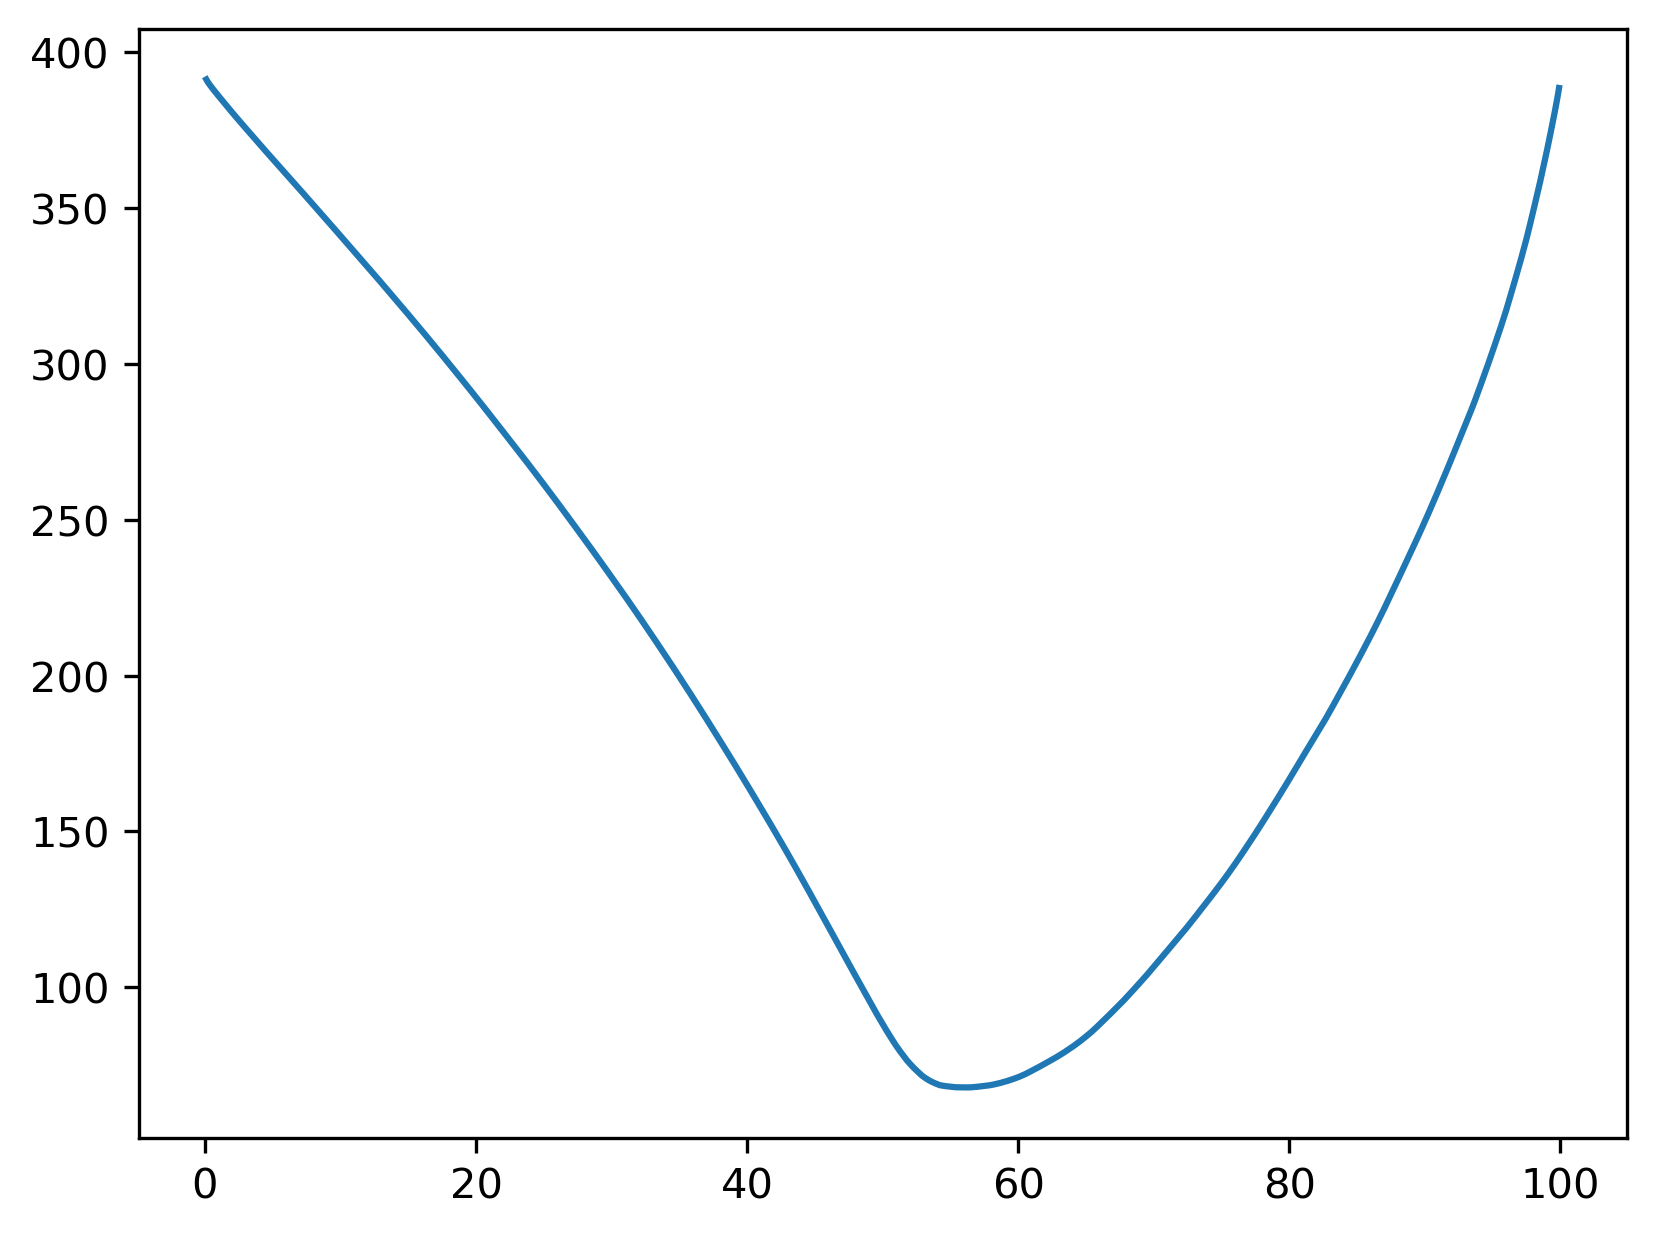

In [11]:
plt.plot(t,cost)
plt.show()

In [12]:
# the thresholding value is
v = np.percentile(data,t[np.argmin(cost)])
print('The thresholding value is : '+str(v))

The thresholding value is : 3.474051425674963


In [13]:
t[np.argmin(cost)]

55.900000000000006

/var/folders/1m/2d5xq3d16t31xt6lgcqz8wlm0000gq/T/ipykernel_7665/3542503502.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(data,


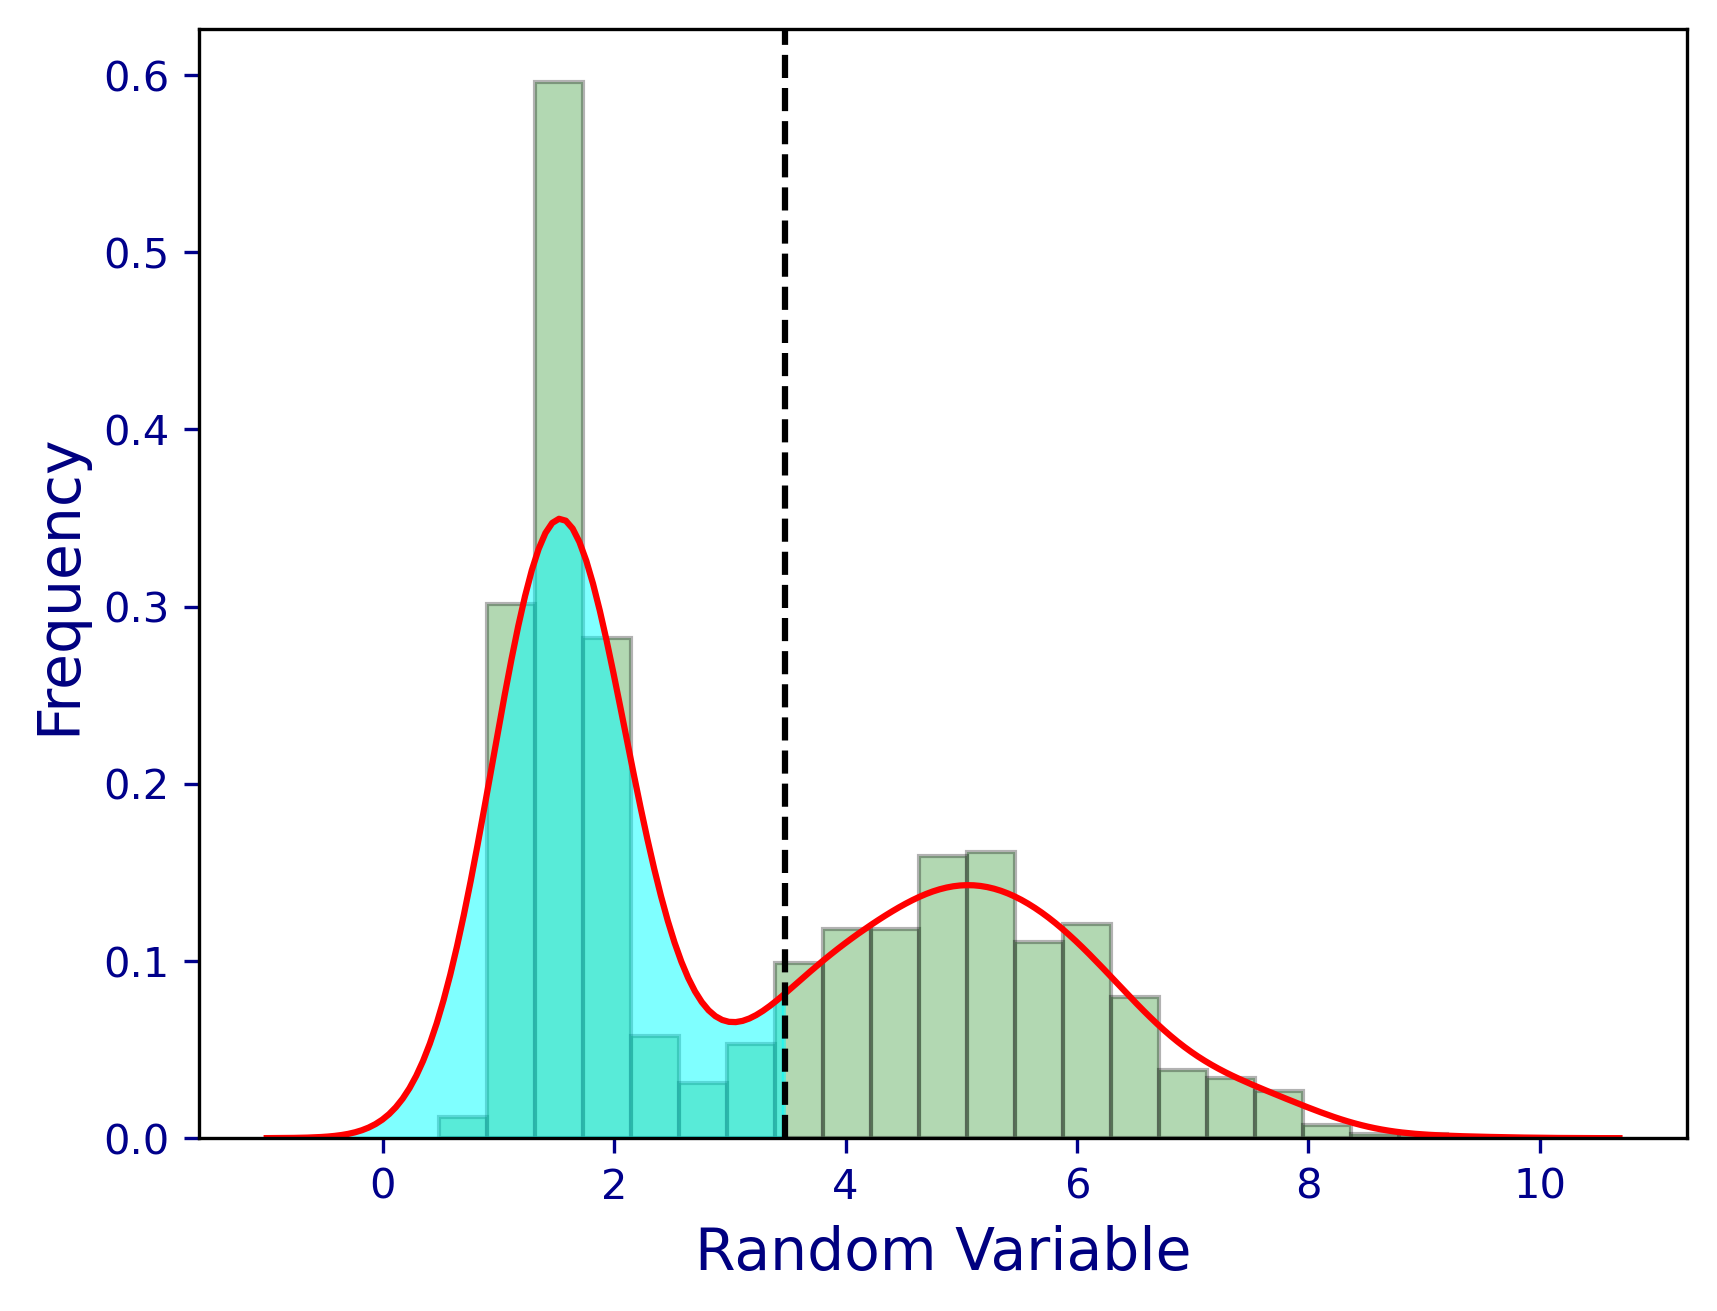

In [14]:
# we show the cut according to Otsu's method
plt.figure()
# then we want to display the histogram and the fit of the underlying distribution:
ax1 = sns.distplot(data,
                  bins=21,
                  kde=True,
                  color='red',
                  hist_kws={'color':'green','alpha':0.3,'edgecolor':'black'},
                  #fit=stats.norm,
                  #fit_kws={"color":'deepskyblue'}
                   )
ax1.set_xlabel('Random Variable',fontsize=14,color='navy')
ax1.set_ylabel('Frequency',fontsize=14,color='navy')
l1 = ax1.lines[0]
plt.axvline(x=v, color='black',linestyle='dashed')

x = l1.get_xydata()[:,0]
y = l1.get_xydata()[:,1]
plt.tick_params(axis='x', colors='darkblue')
plt.tick_params(axis='y', colors='darkblue')
ax1.fill_between(x,y, where = x <= v, color='cyan',alpha=0.5)
plt.show()

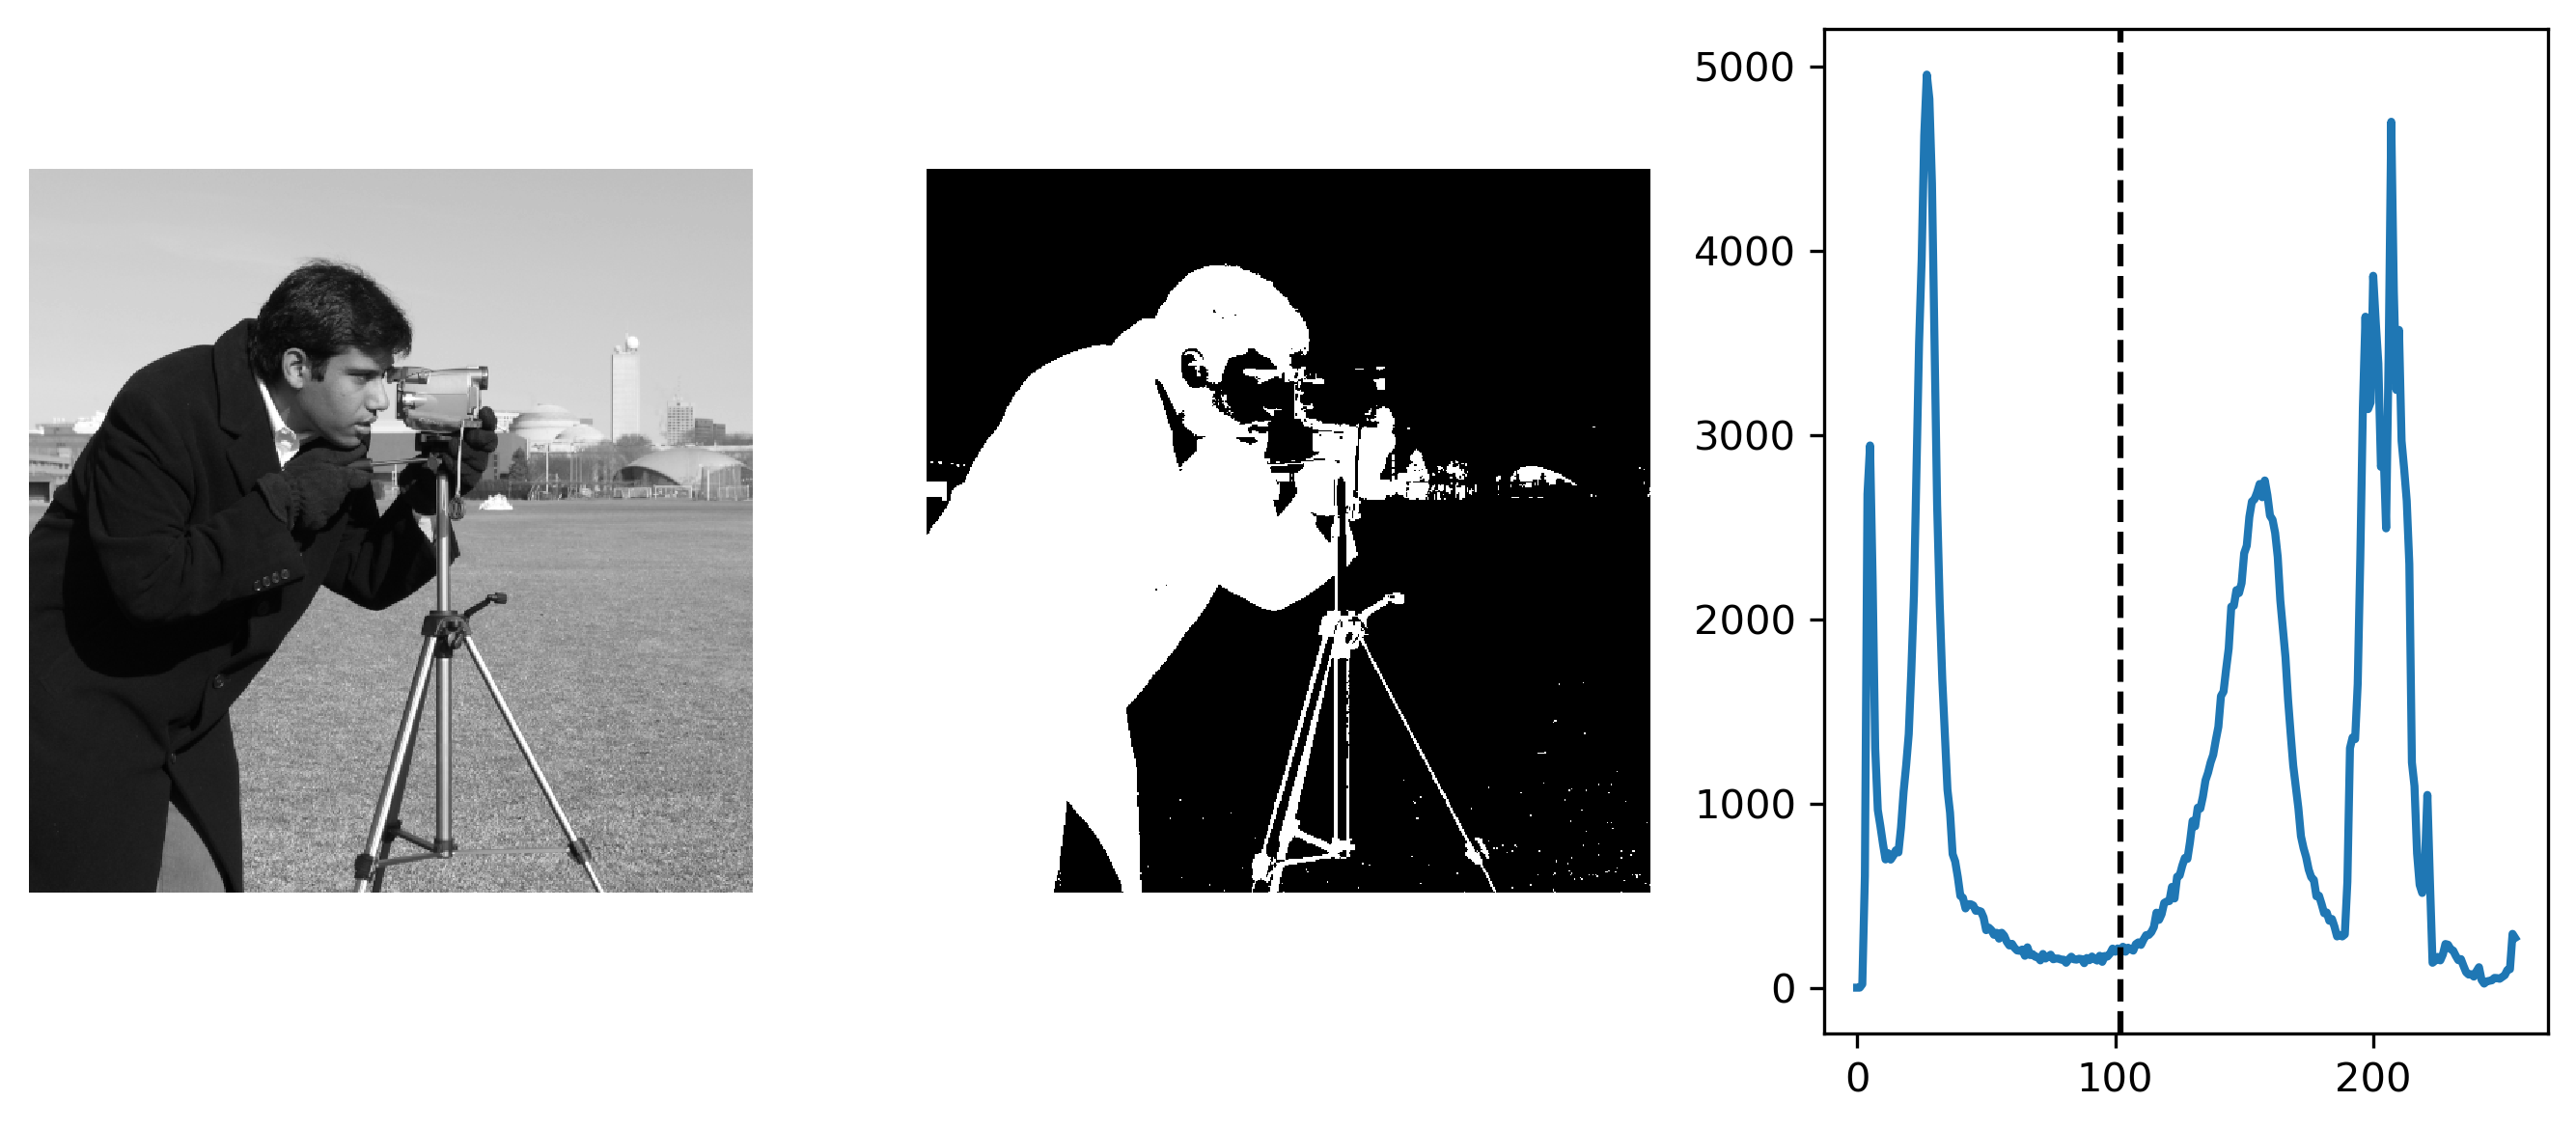

In [15]:
from skimage import data
from skimage import filters
from skimage import exposure

camera = data.camera()
val = filters.threshold_otsu(camera)

hist, bins_center = exposure.histogram(camera)

plt.figure(figsize=(9, 4))
plt.subplot(131)
plt.imshow(camera, cmap='gray', interpolation='nearest')
plt.axis('off')
plt.subplot(132)
plt.imshow(camera < val, cmap='gray', interpolation='nearest')
plt.axis('off')
plt.subplot(133)
plt.plot(bins_center, hist, lw=2)
plt.axvline(val, color='k', ls='--')

plt.tight_layout()
plt.show()